In [3]:
# Let's see the accuracy of simple models like logistic regression and decision tree on the MNIST dataset.
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

df = pd.read_csv("./dataset/train.csv")

X, y = df.drop(columns=["label"]), df["label"]

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

print(f"Logistic Regression Accuracy: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")



/Users/dan.popa/work/kaggle_getting_started/digit_recognizer/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/dan.popa/work/kaggle_getting_started/digit_recognizer/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also wan

Logistic Regression Accuracy: 0.9007 ± 0.0030


/Users/dan.popa/work/kaggle_getting_started/digit_recognizer/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"Random Forest Accuracy: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")


Random Forest Accuracy: 0.9641 ± 0.0022


In [6]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(random_state=42)
lgbm_scores = cross_val_score(lgbm_model, X, y, cv=5, scoring='accuracy')
print(f"LGBM Accuracy: {lgbm_scores.mean():.4f} ± {lgbm_scores.std():.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 102744
[LightGBM] [Info] Number of data points in the train set: 33600, number of used features: 615
[LightGBM] [Info] Start training from score -2.319090
[LightGBM] [Info] Start training from score -2.193571
[LightGBM] [Info] Start training from score -2.307957
[LightGBM] [Info] Start training from score -2.267206
[LightGBM] [Info] Start training from score -2.333413
[LightGBM] [Info] Start training from score -2.403985
[LightGBM] [Info] Start training from score -2.317578
[LightGBM] [Info] Start training from score -2.255781
[LightGBM] [Info] Start training from score -2.335871
[LightGBM] [Info] Start training from score -2.305566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039060 seconds.


Let's try some deep learning now. Images are not really tabular data.

/Users/dan.popa/work/kaggle_getting_started/digit_recognizer/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6938 - loss: 0.9837 - val_accuracy: 0.9313 - val_loss: 0.2337
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9181 - loss: 0.2721 - val_accuracy: 0.9493 - val_loss: 0.1714
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9404 - loss: 0.1935 - val_accuracy: 0.9554 - val_loss: 0.1442
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9556 - loss: 0.1488 - val_accuracy: 0.9639 - val_loss: 0.1215
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9600 - loss: 0.1323 - val_accuracy: 0.9662 - val_loss: 0.1092
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9661 - loss: 0.1124 - val_accuracy: 0.9689 - val_loss: 0.1040
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9681 - loss: 0.1041 - val_accuracy: 0.9695 - val_loss: 0.0976
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9725 - loss: 0.0862 - val_accuracy: 0.

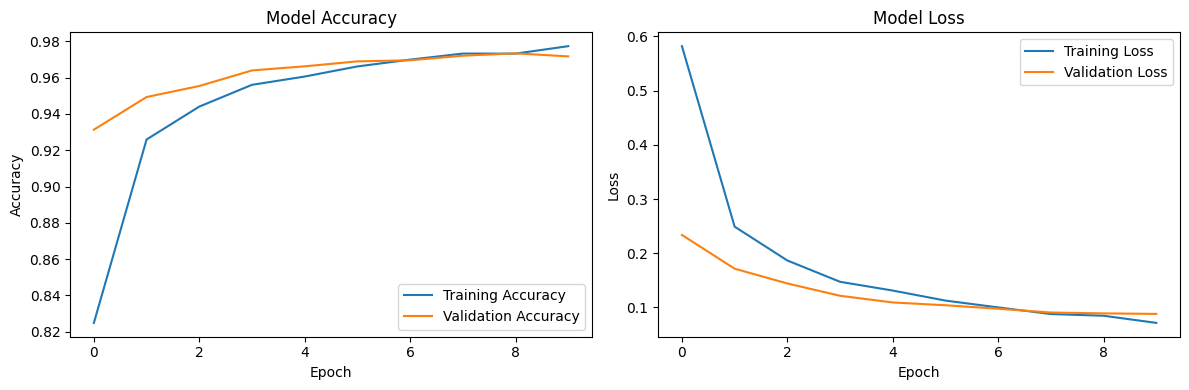

In [ ]:
# basic Dense network using Keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import numpy as np

# Prepare data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to numpy arrays and normalize
X_train_keras = X_train.values.astype('float32') / 255.0
X_val_keras = X_val.values.astype('float32') / 255.0
y_train_keras = y_train.values
y_val_keras = y_val.values

# Create the model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')  # softmax for multi-class classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # for integer labels
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Train the model
history = model.fit(
    X_train_keras, y_train_keras,
    batch_size=128,
    epochs=10,
    validation_data=(X_val_keras, y_val_keras),
    verbose=1
)

# Evaluate the model
val_loss, val_accuracy = model.evaluate(X_val_keras, y_val_keras, verbose=0)
print(f"\nFinal Validation Accuracy: {val_accuracy*100:.2f}%")

# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot training & validation accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot training & validation loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8024 - loss: 0.6372 - val_accuracy: 0.9746 - val_loss: 0.0811
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9706 - loss: 0.0950 - val_accuracy: 0.9815 - val_loss: 0.0596
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9805 - loss: 0.0641 - val_accuracy: 0.9847 - val_loss: 0.0504
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9840 - loss: 0.0512 - val_accuracy: 0.9862 - val_loss: 0.0438
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9873 - loss: 0.0409 - val_accuracy: 0.9882 - val_loss: 0.0381
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9892 - loss: 0.0336 - val_accuracy: 0.9902 - val_loss: 0.0390
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9911 - loss: 0.0296 - val_accuracy: 0.9897 - val_loss: 0.0373
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9922 - loss: 0.0242 - val_accu

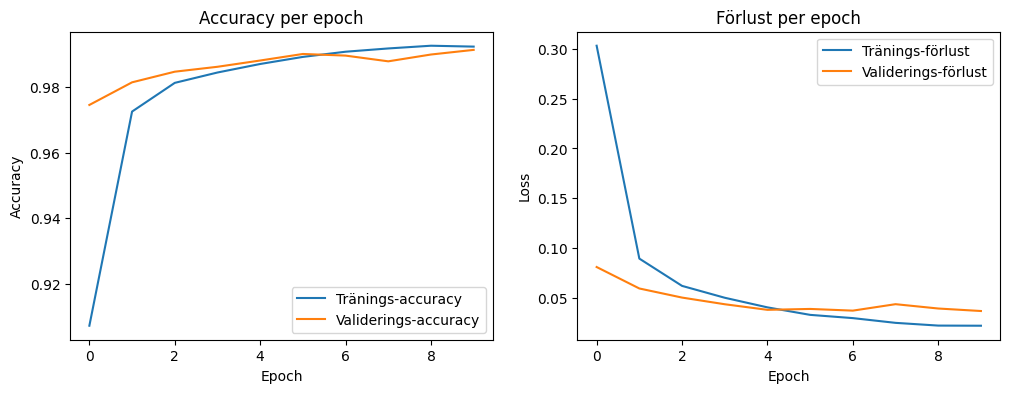

In [ ]:
# we get a good accuracy of 97% with a simple dense network.
# Now let's try a convolutional neural network (CNN) for better performance on image data.


import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalisera pixlar till 0-1 och lägg till kanal-dimension (28,28,1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train[..., tf.newaxis]  # shape blir (num_samples, 28, 28, 1)
X_test = X_test[..., tf.newaxis]

# Bygg CNN-modell
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')  # 10 klasser för siffror 0-9
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Träna modellen
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

# Utvärdera på testdata
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Rita träningshistorik
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Tränings-accuracy')
plt.plot(history.history['val_accuracy'], label='Validerings-accuracy')
plt.title('Accuracy per epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Tränings-förlust')
plt.plot(history.history['val_loss'], label='Validerings-förlust')
plt.title('Förlust per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [11]:
# we get 99.17% but let's try to optimize our layers' numbers

from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import RandomSearch

def build_model(hp):
    model = keras.Sequential()

    # First Conv2D
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_1_filters', [32, 64, 128]),
        kernel_size=hp.Choice('conv_1_kernel', [3, 5]),
        activation='relu',
        input_shape=(28, 28, 1)
    ))
    model.add(layers.MaxPooling2D((2,2)))

    # Second Conv2D
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_2_filters', [64, 128]),
        kernel_size=hp.Choice('conv_2_kernel', [3, 5]),
        activation='relu'
    ))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())

    # Dense layer
    model.add(layers.Dense(
        units=hp.Choice('dense_units', [32, 64, 128]),
        activation='relu'
    ))

    # Dropout
    model.add(layers.Dropout(
        rate=hp.Choice('dropout_rate', [0.1, 0.2, 0.3])
    ))

    # Output
    model.add(layers.Dense(10, activation='softmax'))

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,   # try 10 different combinations
    executions_per_trial=1,
    directory='mnist_tuner',
    project_name='digit_model'
)

# Load and preprocess MNIST
(x_train, y_train), (x_val, y_val) = keras.datasets.mnist.load_data()
x_train = x_train[..., None] / 255.0
x_val = x_val[..., None] / 255.0

# Start tuning
tuner.search(x_train, y_train,
             epochs=5,
             validation_data=(x_val, y_val))

best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Trial 10 Complete [00h 33m 12s]
val_accuracy: 0.9926000237464905

Best val_accuracy So Far: 0.9932000041007996
Total elapsed time: 00h 55m 23s


/Users/dan.popa/work/kaggle_getting_started/digit_recognizer/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 128)    │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561,930 (2.14 MB)

 Trainable params: 561,930 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Let's evaluate the best model

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalisera pixlar till 0-1 och lägg till kanal-dimension (28,28,1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train[..., tf.newaxis]  # shape blir (num_samples, 28, 28, 1)
X_test = X_test[..., tf.newaxis]

# Bygg CNN-modell
model = best_model.copy()  # Use the best model from tuning

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Träna modellen
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

# Utvärdera på testdata
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Rita träningshistorik
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Tränings-accuracy')
plt.plot(history.history['val_accuracy'], label='Validerings-accuracy')
plt.title('Accuracy per epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Tränings-förlust')
plt.plot(history.history['val_loss'], label='Validerings-förlust')
plt.title('Förlust per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

KeyError: (Ellipsis, None)

In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

# Prepare data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Normalize pixel values to [0, 1] range
X_train_tensor = X_train_tensor / 255.0
X_val_tensor = X_val_tensor / 255.0

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Initialize model, loss function, and optimizer
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_dataloader:
            outputs = model(batch_X)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')

print(f"\nFinal Validation Accuracy: {val_accuracies[-1]:.2f}%")

Epoch [1/10], Loss: 0.6626, Val Accuracy: 91.30%
Epoch [2/10], Loss: 0.2778, Val Accuracy: 94.29%
Epoch [3/10], Loss: 0.2062, Val Accuracy: 95.24%
Epoch [4/10], Loss: 0.1663, Val Accuracy: 95.95%
Epoch [5/10], Loss: 0.1379, Val Accuracy: 96.14%
Epoch [6/10], Loss: 0.1216, Val Accuracy: 96.57%
Epoch [7/10], Loss: 0.1072, Val Accuracy: 96.40%
Epoch [8/10], Loss: 0.0973, Val Accuracy: 96.83%
Epoch [9/10], Loss: 0.0858, Val Accuracy: 97.12%
Epoch [10/10], Loss: 0.0811, Val Accuracy: 97.08%

Final Validation Accuracy: 97.08%
